# Ôn tập giữa kỳ


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [17]:
df = pd.read_csv('brfss_2000.csv')
df.head()

,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth
0,0,1,0,70,175,175,77,m,good
1,0,1,1,64,125,115,33,f,good
2,1,1,1,60,105,105,49,f,good
3,1,1,0,66,132,124,42,f,good
4,0,1,0,61,150,130,55,f,very good


## ĐỀ BÀI

Hệ thống giám sát rủi ro dựa trên hành vi (The Behavior Risk Factor Surveilance System - BRFSS) là một cuộc khảo sát qua điện thoại hàng năm với 350.000 người ở Hoa Kỳ. Như tên gọi của nó, BRFSS được thiết kế để xác định các yếu tố nguy cơ ở người trưởng thành và báo cáo các xu hướng sức khỏe mớ. Ví dụ, người trả lời được hỏi về chế độ ăn uống và hoạt động thể chất hàng tuần, tình trạng HIV/AIDS, khả năng sử dụng thuốc lá và thậm chí cả mức độ chi trả dịch vụ chăm sóc sức khỏe của họ. 

Bộ dữ liệu **brfss_2000** chứa thông tin khảo sát năm 2000, với hơn 200 thông tin. Trong bộ dữ liệu này, ta chỉ khảo sát một số thông tin sau:
-	genhlth: người khảo sát tự đánh giá sức khỏe (excellent, very good, good, fair or poor)
-	exerany: cho biết có hoạt động thể chất nào trong tháng gần nhất hay không, có (1), không (0)
-	hlthplan: có bảo hiểm (1) hay không (0)
-	smoke100: tổng số điếu thuốc đã hút ít nhất
-	height: chiều cao (inches)
-	weight: cân nặng (pounds)
-	wtdesire:  cân nặng mong muốn(pounds)
-	age: tuổi
-	gender: giới tính: nam(m), nữ(f)


### Câu 1:

Đọc hai bộ dữ liệu trên và cho biết mỗi bộ dữ liệu có kích thước bao nhiêu dòng, bao nhiêu cột?

In [3]:
df.shape
# 2000 dòng, 9 cột

(20000, 9)

### Câu 2

a, Tính tỷ lệ nam nữ

b, Trong số những người tập thể thao, tỷ lệ những người tự đánh giá có sức khỏe kém là bao nhiêu?

In [4]:
#a
gender_counts = df["gender"].value_counts()
total = gender_counts.sum()

male = gender_counts.get("m", 0) / total
male_ratio = (male * 100).round(3)
female = gender_counts.get("f", 0) / total
female_ratio = (female * 100).round(3)
print(f'Tỉ lệ nam là: ', male_ratio)
print(f'Tỉ lệ nữ là: ', female_ratio)


Tỉ lệ nam là:  47.845
Tỉ lệ nữ là:  52.155


In [8]:
#b
people_ex = len(df[df["exerany"] == 1])

# Số người tập thể thao nhưng tự đánh giá có sức khỏe kém (fair hoặc poor)
hlt_notgd = len(df[(df["exerany"] == 1) & (df["genhlth"].isin(["fair", "poor"]))])

# Tính tỷ lệ và làm tròn 2 chữ số thập phân
hlt_notgd_ratio = round(hlt_notgd / people_ex, 2)

print(f"Trong số những người tập thể thao, tỷ lệ những người tự đánh giá có sức khỏe kém là: {hlt_notgd_ratio * 100}%")

Trong số những người tập thể thao, tỷ lệ những người tự đánh giá có sức khỏe kém là: 10.0%


### Câu 3

a, Đổi đơn vị chiều cao từ inches sang centimet, đơn vị cân nặng từ pound sang kg.

b, Tính tỷ lệ những người muốn giảm cân.

In [9]:
#a 
# 1 inch = 2.54 cm
# 1 pound = 0.453592 kg
df["height_cm"] = df["height"] * 2.54
df["weight_kg"] = df["weight"] * 0.453592

In [13]:
print(df[['height_cm', 'weight_kg']].head())

   height_cm  weight_kg
0     177.80  79.378600
1     162.56  56.699000
2     152.40  47.627160
3     167.64  59.874144
4     154.94  68.038800


In [17]:
#b
#Những người muốn giảm cân là những người có weight > wtdesire
weight_loss_desire_rate = df[df['wtdesire'] < df['weight']]['wtdesire'].count() / df.shape[0] 
print('Tỷ lệ những người muốn giảm cân:', weight_loss_desire_rate)


Tỷ lệ những người muốn giảm cân: 0.6382


### Câu 4:

a, Theo bạn trong các thuộc tính trên, thuộc tính nào có phân phối chuẩn. Vẽ hình minh họa

b, Vẽ đồ thị boxplot so sánh cân nặng của những người có tập thể dục

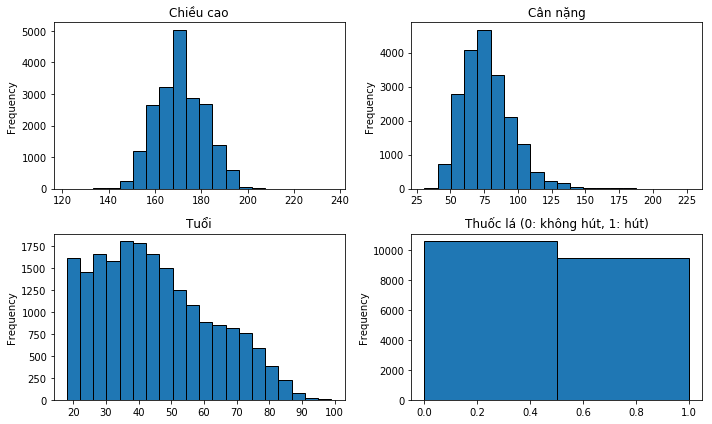

In [20]:
#a
#Các thuộc tính có thể có PPC: chiều cao, cân nặng, iq
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
df['height_cm'].plot(kind='hist', bins=20, title='Chiều cao',edgecolor='black')

plt.subplot(2, 2, 2)
df['weight_kg'].plot(kind='hist', bins=20, title='Cân nặng',edgecolor='black')

plt.subplot(2, 2, 3)
df['age'].plot(kind='hist', bins=20, title='Tuổi',edgecolor='black')

plt.subplot(2, 2, 4)
df['smoke100'].plot(kind='hist', bins=2, title='Thuốc lá (0: không hút, 1: hút)',edgecolor='black')

plt.tight_layout()
plt.show()

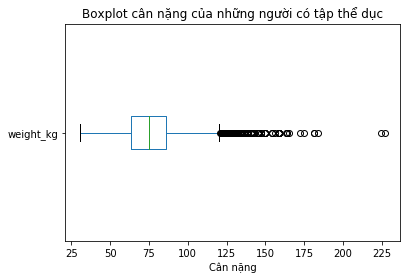

In [24]:
plt.figure(figsize=(6, 4))
df[df['exerany'] == 1]['weight_kg'].plot(kind='box', vert=False)
plt.title('Boxplot cân nặng của những người có tập thể dục')
plt.xlabel('Cân nặng')
plt.show()


### Câu 5

Phân bố tuổi tác trong mẫu: Hãy mô tả phân bố tuổi của người tham gia khảo sát. Tuổi trung bình, độ lệch chuẩn, và các phân vị 25%, 50%, 75% là bao nhiêu?



In [26]:
# Tính các thống kê về tuổi
age_mean = df["age"].mean()  
age_std = df["age"].std() 
age_quartiles = df["age"].quantile([0.25, 0.50, 0.75]) 

# Hiển thị kết quả
print(f"Tuổi trung bình: {age_mean:.2f}")
print(f"Độ lệch chuẩn: {age_std:.2f}")
print("Phân vị tuổi:")
print(age_quartiles)

Tuổi trung bình: 45.07
Độ lệch chuẩn: 17.19
Phân vị tuổi:
0.25    31.0
0.50    43.0
0.75    57.0
Name: age, dtype: float64


### Câu 6

Tỉ lệ người hút thuốc: Tính tỉ lệ phần trăm người tham gia khảo sát hiện đang hút thuốc lá. Liệu có sự khác biệt đáng kể về tỉ lệ này giữa các nhóm tuổi khác nhau không?



In [31]:
# Tính tỷ lệ phần trăm người hút thuốc
smoking_ratio = (df["smoke100"].mean()) * 100

# Chia nhóm tuổi thành các khoảng để so sánh
age_bins = [18, 30, 40, 50, 60, 70, 80, 100] 
age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]

df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=False)

# Tính tỷ lệ hút thuốc theo nhóm tuổi
# smoking_by_age = df.groupby("age_group")["smoke100"].mean() * 100

# print(f"Tỷ lệ phần trăm người hút thuốc trong khảo sát: {smoking_ratio:.2f}%")
# print("\nTỷ lệ hút thuốc theo nhóm tuổi:")
# for age_group, percentage in smoking_by_age.items():
#     print(f"  Nhóm {age_group}: {percentage:.2f}%")

0        70-79
1        30-39
2        40-49
3        40-49
4        50-59
         ...  
19995    18-29
19996    30-39
19997    50-59
19998      80+
19999      80+
Name: age_group, Length: 20000, dtype: category
Categories (7, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70-79' < '80+']

In [33]:
df["age_group"].unique()

['70-79', '30-39', '40-49', '50-59', '18-29', '60-69', '80+']
Categories (7, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70-79' < '80+']

In [35]:
df['age'].unique()

array([77, 33, 49, 42, 55, 31, 45, 27, 44, 46, 62, 21, 69, 23, 79, 47, 76,
       43, 48, 54, 30, 32, 63, 74, 41, 36, 67, 57, 18, 65, 29, 52, 35, 59,
       64, 58, 34, 50, 20, 56, 80, 37, 24, 71, 51, 38, 40, 22, 28, 25, 87,
       61, 75, 26, 53, 39, 66, 60, 78, 84, 82, 70, 72, 68, 85, 19, 86, 81,
       73, 83, 88, 99, 93, 91, 90, 89, 94, 92, 97, 95, 96], dtype=int64)

### Câu 7

BMI trung bình theo giới tính: Tính chỉ số BMI trung bình cho nam và nữ trong mẫu. 



In [25]:
# Tính BMI = (weight (pounds) / (height (inches) ^ 2)) * 703
df["BMI"] = (df["weight"] / (df["height"] ** 2)) * 703

# Tính BMI trung bình theo giới tính
bmi_by_gender = df.groupby("gender")["BMI"].mean()

print("Chỉ số BMI trung bình theo giới tính:")
for gender, bmi in bmi_by_gender.items():
    print(f"  {gender}: {bmi:.2f}")

Chỉ số BMI trung bình theo giới tính:
  f: 25.74
  m: 26.92


### câu 8

Phân tích tỉ lệ bệnh béo phì: Sử dụng các tiêu chuẩn của CDC về chỉ số BMI để phân loại người tham gia vào nhóm béo phì. Tính tỉ lệ béo phì theo giới tính và độ tuổi. 

In [30]:
# Xác định người béo phì (BMI >= 30)
df["obese"] = df["BMI"] >= 30

# Tỷ lệ béo phì theo giới tính
obesity_by_gender = df.groupby("gender")["obese"].mean() * 100

# Tỷ lệ béo phì theo nhóm tuổi
obesity_by_age = df.groupby("age_group")["obese"].mean() * 100

print("Tỷ lệ béo phì theo giới tính:")
for gender, percentage in obesity_by_gender.items():
    print(f"  {gender}: {percentage:.2f}%")

print("\nTỷ lệ béo phì theo nhóm tuổi:")
for age_group, percentage in obesity_by_age.items():
    print(f"  Nhóm {age_group}: {percentage:.2f}%")

Tỷ lệ béo phì theo giới tính:
  f: 18.51%
  m: 20.12%

Tỷ lệ béo phì theo nhóm tuổi:
  Nhóm 18-29: 13.58%
  Nhóm 30-39: 19.45%
  Nhóm 40-49: 22.18%
  Nhóm 50-59: 24.41%
  Nhóm 60-69: 22.81%
  Nhóm 70-79: 16.18%
  Nhóm 80+: 9.93%


In [27]:
# uni = df['age_group'].unique()
# print(uni)
df['BMI']

0        25.107143
1        21.453857
2        20.504167
3        21.303030
4        28.339156
           ...    
19995    34.698118
19996    26.383937
19997    35.940355
19998    25.839831
19999    25.101869
Name: BMI, Length: 20000, dtype: float64

---